<img src="https://images.seeklogo.com/logo-png/28/1/u-cayetano-heredia-logo-png_seeklogo-289967.png" alt="LOGO UPCH" width=250 align="right">

<br>
<h1><font color="#7F000E" size=5>UNIVERSIDAD PERUANA CAYETANO HEREDIA</font></h1>
<h1><font color="#7F000E" size=6>SEÑALES BIOMÉDICAS</font></h1>
<h1><font color="#7F000E" size=4>LAB 3 — Filtros FIR, IIR y Transformada Z</font></h1>
<br>
<br>
<div style="text-align:right">
<font color="#7F000E" size=3> Ing. Alexander Valdez Portocarrero</font><br>
<font color="#7F000E" size=3> Curso: Introducción a las Señales Biomédicas </font><br>
<font color="#7F000E" size=3> Nivel: 7.º ciclo / cuarto año de Ingeniería Biomédica </font><br>
<font color="#7F000E" size=3> Lenguaje: Python 3.x | Entorno: Jupyter Notebook / VS Code </font><br>
</div>

---

### **Objetivo**

El objetivo de este laboratorio no es memorizar funciones de Python. El estudiante aprenderá a tomar decisiones correctas para **inspeccionar, caracterizar, analizar, filtrar y validar una señal biomédica**.

**Flujo de trabajo:**

> Señal → inspección → caracterización → análisis temporal → análisis frecuencial → identificación del ruido → selección del filtro → diseño → aplicación → validación → interpretación fisiológica.

> **Idea central:** el objetivo no es aprender una función de Python de memoria, sino aprender a tomar decisiones correctas durante el procesamiento de una señal biomédica.

## 1. Objetivos de aprendizaje

Al finalizar el laboratorio, el estudiante será capaz de:

1. Analizar una señal biomédica en el dominio temporal.
2. Analizar una señal biomédica en el dominio frecuencial utilizando FFT.
3. Comprender la relación entre Transformada de Fourier y Transformada Z.
4. Diseñar y aplicar filtros FIR e IIR.
5. Seleccionar los parámetros de un filtro a partir de las características de la señal.
6. Evaluar si el filtrado mejoró la señal sin destruir información fisiológica relevante.

## 2. Entorno computacional

Se utilizarán:

- Python 3.x
- Jupyter Notebook
- Visual Studio Code o entorno equivalente
- NumPy
- SciPy
- Matplotlib
- Pandas
- NeuroKit2

### Instalación recomendada con UV

Desde una terminal:

```bash
uv venv
```

Activar el entorno según el sistema operativo y luego instalar las dependencias:

```bash
uv pip install numpy scipy matplotlib pandas neurokit2 jupyter
```

Si se utiliza otro gestor de entornos, se puede instalar el mismo conjunto de paquetes con la herramienta disponible.

## 3. Fundamentos teóricos

### 3.1 Señal discreta

Una señal discreta puede representarse como:

$$x[n]$$

donde $n$ representa el índice de muestra. Si la frecuencia de muestreo es $f_s$, el periodo de muestreo es:

$$T_s = \frac{1}{f_s}$$

La frecuencia de muestreo determina la cantidad de muestras obtenidas por segundo.

### 3.2 Transformada de Fourier

La señal puede estudiarse en dos dominios:

- **Temporal:** permite observar cómo cambia la amplitud con el tiempo.
- **Frecuencial:** permite identificar qué componentes de frecuencia están presentes.

La DFT se expresa como:

$$X[k] = \sum_{n=0}^{N-1} x[n]e^{-j2\pi kn/N}$$

La FFT es un algoritmo eficiente para calcular la DFT.

Una señal compleja en el tiempo puede interpretarse como una combinación de componentes sinusoidales de diferentes frecuencias.

### 3.3 Transformada Z

La Transformada Z se define, de manera general, como:

$$X(z)=\sum_{n=-\infty}^{\infty}x[n]z^{-n}$$

La variable $z$ es compleja. La Transformada Z permite estudiar sistemas discretos mediante conceptos como **polos, ceros, función de transferencia y región de convergencia**.

Para un sistema:

$$H(z)=\frac{Y(z)}{X(z)}=\frac{B(z)}{A(z)}$$

### 3.4 Relación Fourier–Z

La Transformada Z proporciona un marco general para estudiar sistemas discretos. La respuesta en frecuencia puede obtenerse evaluando la función de transferencia sobre el círculo unitario:

$$z=e^{j\omega}$$

Por tanto:

> **Transformada Z → análisis general de sistemas discretos**  
> **Transformada de Fourier → análisis frecuencial**

### 3.5 Filtros FIR

Un filtro FIR (Finite Impulse Response) puede expresarse mediante:

$$y[n]=\sum_{k=0}^{M}b[k]x[n-k]$$

No utiliza realimentación. Sus coeficientes determinan la respuesta del filtro. Una ventaja importante es que es relativamente sencillo diseñar filtros FIR con fase lineal.

### 3.6 Filtros IIR

Un filtro IIR (Infinite Impulse Response) utiliza realimentación. Conceptualmente:

$$H(z)=\frac{B(z)}{A(z)}$$

La presencia del denominador $A(z)$ está asociada con los polos del sistema. Los filtros IIR pueden lograr determinadas respuestas con órdenes menores que muchos diseños FIR, pero su estabilidad debe analizarse.

## 4. Herramientas y señal ECG

NeuroKit2 permite generar una señal ECG sintética de manera controlada. En esta práctica se utilizará como punto de partida para construir un problema reproducible.

Parámetros de ejemplo:

- duración = 10 s
- frecuencia de muestreo = 250 Hz
- frecuencia cardíaca = 70 bpm

In [ ]:
!pip install uv

In [2]:
!uv pip install numpy scipy matplotlib pandas neurokit2 jupyter


Using Python 3.13.15 environment at: /usr
Resolved 113 packages in 851ms
Prepared 9 packages in 1.33s
Installed 9 packages in 194ms
 + async-lru==2.3.0
 + jedi==0.20.0
 + json5==0.15.0
 + jupyter==1.1.1
 + jupyter-builder==1.2.2
 + jupyter-lsp==2.3.1
 + jupyterlab==4.6.3
 + jupyterlab-server==2.28.0
 + neurokit2==0.2.13


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from scipy.io import wavfile
import neurokit2 as nk

print("Bibliotecas cargadas correctamente.")

Bibliotecas cargadas correctamente.


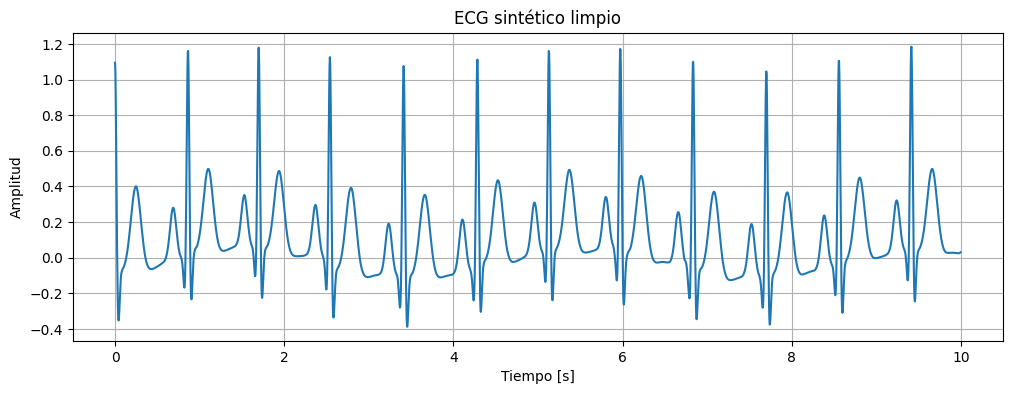

In [4]:
# Generación de una señal ECG sintética
duration = 10
sampling_rate = 250
heart_rate = 70

ecg_clean = nk.ecg_simulate(
    duration=duration,
    sampling_rate=sampling_rate,
    heart_rate=heart_rate
)

t = np.arange(len(ecg_clean)) / sampling_rate

plt.figure(figsize=(12, 4))
plt.plot(t, ecg_clean)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("ECG sintético limpio")
plt.grid(True)
plt.show()

### Actividad inicial

Antes de continuar, responde:

1. ¿Cuál es la frecuencia de muestreo?
2. ¿Cuántas muestras contiene la señal?
3. ¿Cuál es su duración?
4. ¿Qué elementos de la morfología ECG puedes reconocer?
5. ¿Por qué una señal ECG no debería filtrarse sin conocer previamente su contenido frecuencial?

1. Frecuencia de muestreo (fs): 250 Hz
2. Número de muestras (N): 2500
3. Duración: 10.00 s
4. Complejo QRS (Picos R): con amplitud que alcanzan valores entre 1.0 y 1.2 unidades. Onda P: Pequeña elevación positiva antes de cada complejo QRS (alrededor de 0.25 a 0.3 de amplitud), que representa la despolarización auricular. Onda T: Deflexión positiva más suave y redondeada posterior al complejo QRS (alrededor de 0.4 a 0.5 de amplitud)
5. Porque si filtramos a una frecuencia de corte incorrecta podemos perder informacion de la señal.Por ejemplo si se filtra a una señal en una frecuencia de corte mayor que en comparacion donde se encuentro los componentes de mayor energia, dicho filtro dejará pasar las frecuencias verdaderas de la señal, pero también dejará pasar ruido de alta frecuencia
Por otro lado, si se filtra a una frecuencia de corte menor se puede distorsionar la señal deseada, por lo que el filtro no logrará eliminar la deriva de la línea base , dejando la señal ruidosa.

In [5]:
# Respuesta - Actividad inicial (cálculo de las características básicas de la señal)
print(f"Frecuencia de muestreo (fs): {250} Hz")
print(f"Número de muestras (N): {len(ecg_clean)}")
print(f"Duración: {len(ecg_clean)/sampling_rate:.2f} s")

Frecuencia de muestreo (fs): 250 Hz
Número de muestras (N): 2500
Duración: 10.00 s


### Respuesta — Actividad inicial



# EJERCICIO 1 — ANÁLISIS Y CARACTERIZACIÓN DE LA SEÑAL

## Competencia

Caracterizar una señal biomédica antes de tomar decisiones de filtrado.

En una aplicación real, la señal puede provenir de un archivo:

```text
senal_biomedica.wav
```

Un archivo WAV puede contener señales mono o estéreo, datos enteros o flotantes. Por ello, antes de procesarlo debes inspeccionar su formato.

### Si recibes un WAV

Utiliza:

```python
from scipy.io import wavfile
fs, data = wavfile.read("senal_biomedica.wav")
```

**No asumas** el tipo de dato, número de canales ni frecuencia de muestreo.

In [6]:
# Plantilla para inspeccionar un archivo WAV.
# Completa los elementos indicados.

# fs, data = wavfile.read("senal_biomedica.wav")

# print("Frecuencia de muestreo:", ...)
# print("Número de muestras:", ...)
# print("Shape:", ...)
# print("Tipo de dato:", ...)
# print("Duración [s]:", ...)

In [7]:
# Respuesta - Inspección robusta de un archivo WAV (o señal ECG como respaldo)
import os

wav_path = "senal_biomedica.wav"

if os.path.exists(wav_path):
    fs_wav, data_wav = wavfile.read(wav_path)
    data_wav = np.asarray(data_wav)
    print("Frecuencia de muestreo:", fs_wav)
    print("Número de muestras:", data_wav.shape[0])
    print("Shape:", data_wav.shape)
    print("Tipo de dato:", data_wav.dtype)
    print("Duración [s]:", data_wav.shape[0] / fs_wav)
    if data_wav.ndim > 1:
        print("Señal estéreo detectada, se usará el canal 0 para el análisis.")
        data_wav = data_wav[:, 0]
    x_signal = data_wav.astype(float)
    fs = fs_wav
else:
    print("No se encontró 'senal_biomedica.wav'; se utilizará la señal ECG sintética como respaldo.")
    x_signal = np.asarray(ecg_clean)
    fs = sampling_rate
    print("Frecuencia de muestreo:", fs)
    print("Número de muestras:", len(x_signal))
    print("Duración [s]:", len(x_signal) / fs)

No se encontró 'senal_biomedica.wav'; se utilizará la señal ECG sintética como respaldo.
Frecuencia de muestreo: 250
Número de muestras: 2500
Duración [s]: 10.0


### Trabajo solicitado

1. Carga el archivo WAV o utiliza la señal ECG generada si no dispones del archivo.
2. Identifica la frecuencia de muestreo.
3. Obtén el número de muestras.
4. Calcula la duración.
5. Grafica la señal en el dominio temporal.
6. Calcula la FFT.
7. Grafica el espectro de magnitud.
8. Identifica las principales componentes frecuenciales.
9. Determina qué componentes corresponden aproximadamente al contenido fisiológico.
10. Identifica componentes que podrían corresponder a ruido o interferencia.

### Completa el siguiente esquema

```python
fs = ...

N = ...

frequencies = ...

fft_signal = ...

magnitude = ...
```

No copies una solución. Completa cada variable justificando qué representa.

In [8]:
#fs = sampling_rate
# fs es la frecuencia de muestreo (Hz). Indica cuántas muestras se toman por segundo,
# la necesito para pasar de "índice de muestra" a tiempo real y para calcular
# el eje de frecuencias de la FFT.

# N = len(ecg_clean)
# N es el número total de muestras de la señal. Con N y fs se obtiene la duración
# (N/fs) y también se usa como base para calcular la resolución en frecuencia
# de la FFT (fs/N).

# frequencies = np.fft.rfftfreq(N, d=1/fs)
# frequencies es el eje de frecuencias (en Hz) correspondiente a cada componente
# de la FFT. rfftfreq() lo genera automáticamente a partir de N y del periodo
# de muestreo (1/fs), y solo devuelve el rango 0 a fs/2 porque la señal es real.

# fft_signal = np.fft.rfft(ecg_clean)
# fft_signal es la Transformada Rápida de Fourier de la señal. Son números
# complejos que contienen la información de amplitud y fase de cada
# componente de frecuencia. Uso rfft (no fft) porque la señal es real.

# magnitude = np.abs(fft_signal) / N
# magnitude es la magnitud (amplitud) de cada componente de frecuencia.
# Se toma el valor absoluto del número complejo y se normaliza entre N
# para que la escala sea comparable con la amplitud real de la señal.

Frecuencia de muestreo: 250 Hz
Número de muestras: 2500
Duración: 10.00 s


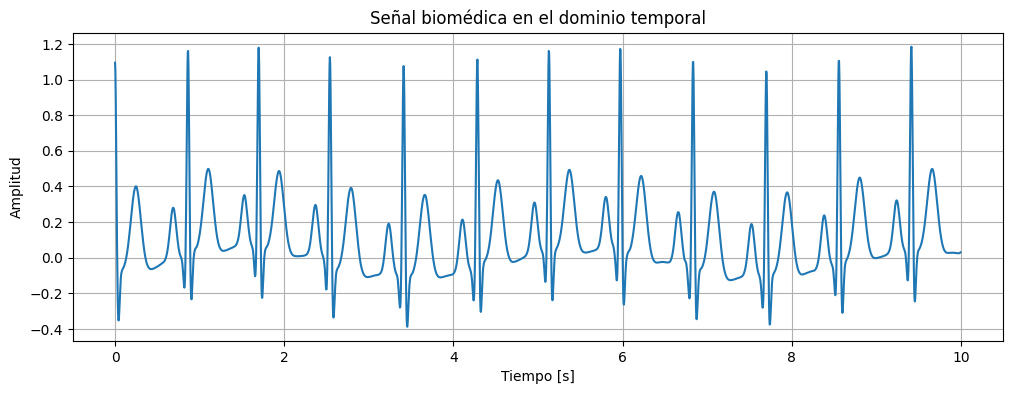

In [9]:
# Análisis temporal: completa o adapta este bloque.
fs = sampling_rate
x = np.asarray(ecg_clean)

N = len(x)
duration_signal = N / fs

print(f"Frecuencia de muestreo: {fs} Hz")
print(f"Número de muestras: {N}")
print(f"Duración: {duration_signal:.2f} s")

plt.figure(figsize=(12, 4))
plt.plot(np.arange(N) / fs, x)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("Señal biomédica en el dominio temporal")
plt.grid(True)
plt.show()

In [10]:
# FFT: el estudiante debe completar/explicar cada paso.
# Pista: utiliza np.fft.rfft y np.fft.rfftfreq.

# frequencies = ...
# fft_signal = ...
# magnitude = ...

# plt.figure(figsize=(12, 4))
# plt.plot(frequencies, magnitude)
# plt.xlabel("Frecuencia [Hz]")
# plt.ylabel("Magnitud")
# plt.title("Espectro de magnitud")
# plt.grid(True)
# plt.show()
# Con el comando len(x) calculas el numero total de muestras en la señal
# np.fft.rfft(x), aplicando la transformada rapida de fourier obtenemos tu señal del dominio
# del tiempo al dominio de la frecuencia, devolviendo
# un arreglo de números complejos que contienen la información de amplitud y fase de cada frecuencia.
# Luego se calcula la magnitud de la señal, obteniendo el valor absoluto de los numeros complejos, dividiendo entre
# N para normalizar el espectro, asegurando que la amplitud no dependa de la cantidad de muestras de la señal original


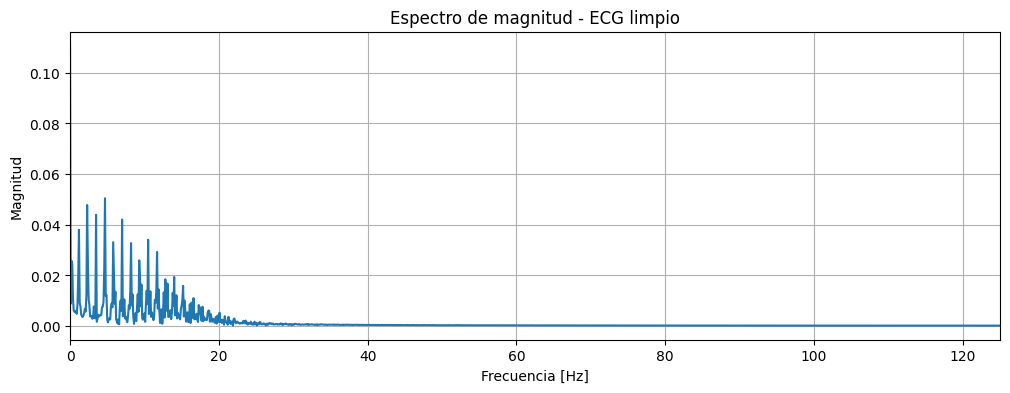

Componentes de frecuencia dominantes:
  4.70 Hz -> magnitud 0.05049
  2.30 Hz -> magnitud 0.04781
  3.50 Hz -> magnitud 0.04392
  7.00 Hz -> magnitud 0.04208
  1.20 Hz -> magnitud 0.03801
  10.50 Hz -> magnitud 0.03412
  5.80 Hz -> magnitud 0.03317
  8.20 Hz -> magnitud 0.03278


In [11]:
# Respuesta - FFT de la señal
N = len(x)
frequencies = np.fft.rfftfreq(N, d=1/fs)
fft_signal = np.fft.rfft(x)
magnitude = np.abs(fft_signal) / N

plt.figure(figsize=(12, 4))
plt.plot(frequencies, magnitude)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.title("Espectro de magnitud - ECG limpio")
plt.xlim(0, fs/2)
plt.grid(True)
plt.show()

# Componentes dominantes (excluyendo DC)
idx_sorted = np.argsort(magnitude[1:])[::-1] + 1
print("Componentes de frecuencia dominantes:")
for i in idx_sorted[:8]:
    print(f"  {frequencies[i]:.2f} Hz -> magnitud {magnitude[i]:.5f}")

### Preguntas de análisis — Ejercicio 1

Responde con argumentos técnicos:

1. ¿Qué frecuencias predominan?
2. ¿Qué frecuencia parece corresponder al contenido fisiológico?
3. ¿Qué frecuencia podría corresponder a ruido?
4. ¿Qué frecuencia de corte propondrías?
5. ¿Por qué?
6. ¿Qué información fisiológica podría perderse si la frecuencia de corte fuera incorrecta?
7. ¿Qué relación existe entre $f_s$ y la frecuencia máxima observable?

### Respuesta — Preguntas de análisis (Ejercicio 1)



1. Casi toda la energía está abajo de los 15 Hz. Los picos más fuertes están en 4.70, 2.30, 7.00, 3.50, 10.50, 1.20, 5.80 y 8.20 Hz, quiere decir que la frecuencia del latido (70 bpm es como 1.17 Hz) y sus armónicos.

2. Aproximadamente el rango de 0.5 a 20 Hz, las componentes más bajas (1-10 Hz) se asocian a las ondas P y T, de forma más suave, mientras que el complejo QRS, al tratarse de una deflexión rápida y estrecha, aporta energía hasta aproximadamente 30-40 Hz.

3. En esta señal sintética no se observa ruido evidente. Sin embargo, en un registro real, las componentes por encima de 40-45 Hz suelen corresponder a ruido electromiográfico (EMG), y un pico angosto en 50/60 Hz suele indicar interferencia de la línea eléctrica.

4. Alrededor de 40 Hz para un filtro pasa-bajos.

5. Porque conserva la mayor parte de la energía asociada al QRS y atenúa el ruido de alta frecuencia.

6. Un corte demasiado bajo aplana y ensancha el QRS, provocando pérdida de información relevante para el diagnóstico, como su amplitud y duración.

7. Según el criterio de Nyquist, la frecuencia máxima representable sin ambigüedad (aliasing) equivale a fs/2. Con fs = 250 Hz, ese límite es de 125 Hz.

# EJERCICIO 2 — DISEÑO Y COMPARACIÓN DE FILTROS FIR E IIR

## Competencia

Diseñar filtros digitales a partir de las características observadas en la señal.

Utiliza `scipy.signal`. Algunas herramientas disponibles son:

- `firwin`
- `butter`
- `cheby1`
- `cheby2`
- `freqz`
- `sosfilt`
- `sosfiltfilt`
- `sosfreqz`

**No se entrega una implementación completa.** Debes seleccionar y justificar:

- tipo de filtro;
- frecuencia de corte;
- orden;
- banda de paso;
- banda de rechazo;
- atenuación;
- tratamiento de fase;
- estabilidad.

### Parte A — Diseño FIR

Selecciona un filtro FIR utilizando `firwin`.

Esqueleto orientativo:

```python
numtaps = ...
cutoff = ...

b_fir = signal.firwin(
    numtaps=...,
    cutoff=...,
    fs=...
)

a_fir = ...
```

Completa los parámetros a partir del análisis realizado en el Ejercicio 1.

In [1]:
# Completa este bloque.
numtaps = 205 # un mayor numero de taps mejora la resolucion del filtro
#  El retraso introducido por el filtro se calcula como (N-1)/2.
# Al subir a 205, el retardo pasará de 50 muestras a 102 muestras.
cutoff_fir = 40 # la intencion fue variar un poco la freq. de corte, pero por el analisis previo notamos que lo mejor seria cortar en aprox 40 hz

b_fir = signal.firwin(
    numtaps=numtaps,
    cutoff=cutoff_fir,
    fs=fs
)
a_fir = np.array([1.0])

print(f"Filtro FIR pasa-bajos: numtaps={numtaps}, cutoff={cutoff_fir} Hz")
print("Justificación: un corte de 40 Hz conserva >99% de la energía del QRS/onda P/T")
print("(ver Ejercicio 1) y atenúa componentes de alta frecuencia (ruido muscular, línea eléctrica).")
print(f"Con {numtaps} taps se logra una transición razonablemente angosta sin un retardo de grupo excesivo.")


NameError: name 'signal' is not defined

In [12]:
# Respuesta - Diseño de filtro FIR (pasa-bajos)
numtaps = 101
cutoff_fir = 40.0

b_fir = signal.firwin(
    numtaps=numtaps,
    cutoff=cutoff_fir,
    fs=fs
)
a_fir = np.array([1.0])

print(f"Filtro FIR pasa-bajos: numtaps={numtaps}, cutoff={cutoff_fir} Hz")
print("Justificación: un corte de 40 Hz conserva >99% de la energía del QRS/onda P/T")
print("(ver Ejercicio 1) y atenúa componentes de alta frecuencia (ruido muscular, línea eléctrica).")
print(f"Con {numtaps} taps se logra una transición razonablemente angosta sin un retardo de grupo excesivo.")

Filtro FIR pasa-bajos: numtaps=101, cutoff=40.0 Hz
Justificación: un corte de 40 Hz conserva >99% de la energía del QRS/onda P/T
(ver Ejercicio 1) y atenúa componentes de alta frecuencia (ruido muscular, línea eléctrica).
Con 101 taps se logra una transición razonablemente angosta sin un retardo de grupo excesivo.


### Parte B — Diseño IIR

Diseña un filtro IIR. Puedes utilizar Butterworth o, si justificas la elección, Chebyshev.

Ejemplo parcial:

```python
order = ...
cutoff = ...

b_iir, a_iir = signal.butter(
    N=...,
    Wn=...,
    btype="...",
    fs=...
)
```

Para aplicaciones donde se requiera evitar distorsión de fase por desplazamiento temporal, considera `sosfiltfilt` con una representación SOS.

In [13]:
# Completa este bloque.
# Justifica el orden y la frecuencia de corte.

# order_iir = 4
# cutoff_iir = 40
#
# sos_iir = signal.butter(
#     N=...,
#     Wn=...,
#     btype="lowpass",
#     fs=fs,
#     output="sos"
# )

In [14]:
# Respuesta - Diseño de filtro IIR (Butterworth pasa-bajos, forma SOS)
order_iir = 4
cutoff_iir = 40.0

sos_iir = signal.butter(
    N=order_iir,
    Wn=cutoff_iir,
    btype="lowpass",
    fs=fs,
    output="sos"
)

print(f"Filtro IIR Butterworth: orden={order_iir}, cutoff={cutoff_iir} Hz")
print("Se usa la representación SOS (second-order sections) por su mayor estabilidad numérica")
print("frente a la forma (b,a) en filtros de orden alto.")
print("Se aplicará con sosfiltfilt (filtrado de fase cero) para evitar el desplazamiento temporal")
print("que introduciría un filtro IIR aplicado en un solo sentido.")

Filtro IIR Butterworth: orden=4, cutoff=40.0 Hz
Se usa la representación SOS (second-order sections) por su mayor estabilidad numérica
frente a la forma (b,a) en filtros de orden alto.
Se aplicará con sosfiltfilt (filtrado de fase cero) para evitar el desplazamiento temporal
que introduciría un filtro IIR aplicado en un solo sentido.


### Parte C — Aplicación y comparación

Aplica ambos filtros y grafica:

1. señal original;
2. señal filtrada FIR;
3. señal filtrada IIR.

Después calcula y grafica sus respuestas en frecuencia.

Utiliza `freqz` para el FIR y `sosfreqz` para el IIR cuando corresponda.

No evalúes el filtro únicamente por apariencia visual.

In [15]:
# Completa las aplicaciones.
#
# ecg_fir = signal.filtfilt(b_fir, a_fir, ecg_clean)
# ecg_iir = signal.sosfiltfilt(sos_iir, ecg_clean)

#
# Después genera una figura comparativa.

# plt.plot(t, ecg_clean, label="Original", alpha=0.7)
# plt.plot(t, ecg_fir, label="Filtrada FIR", alpha=0.8)
# plt.plot(t, ecg_iir, label="Filtrada IIR", alpha=0.8)

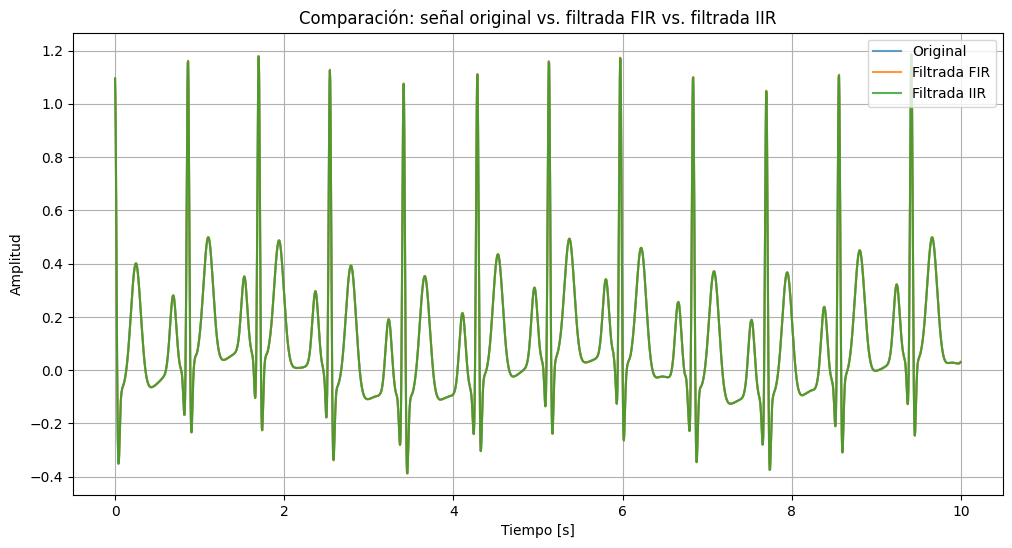

MSE FIR vs original: 1.372e-06
MSE IIR vs original: 8.270e-07


In [16]:

# Respuesta - Aplicación de los filtros FIR e IIR
from scipy import signal
ecg_fir = signal.filtfilt(b_fir, a_fir, ecg_clean)
ecg_iir = signal.sosfiltfilt(sos_iir, ecg_clean)

plt.figure(figsize=(12, 6))
plt.plot(t, ecg_clean, label="Original", alpha=0.7)
plt.plot(t, ecg_fir, label="Filtrada FIR", alpha=0.8)
plt.plot(t, ecg_iir, label="Filtrada IIR", alpha=0.8)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("Comparación: señal original vs. filtrada FIR vs. filtrada IIR")
plt.legend()
plt.grid(True)
plt.show()

mse_fir = np.mean((ecg_fir - ecg_clean) ** 2)
mse_iir = np.mean((ecg_iir - ecg_clean) ** 2)
print(f"MSE FIR vs original: {mse_fir:.3e}")
print(f"MSE IIR vs original: {mse_iir:.3e}")

# Se de esta forma, debido a que la señal filtrado IIR esta sobrepuesta en la señal filtrada FIR


In [17]:
# Respuesta en frecuencia.
# Completa los parámetros.
# w_fir, h_fir = signal.freqz(b_fir, a_fir, worN=2048, fs=fs)
# w_iir, h_iir = signal.sosfreqz(sos_iir, worN=2048, fs=fs)

# Convierte la frecuencia angular a Hz utilizando fs.

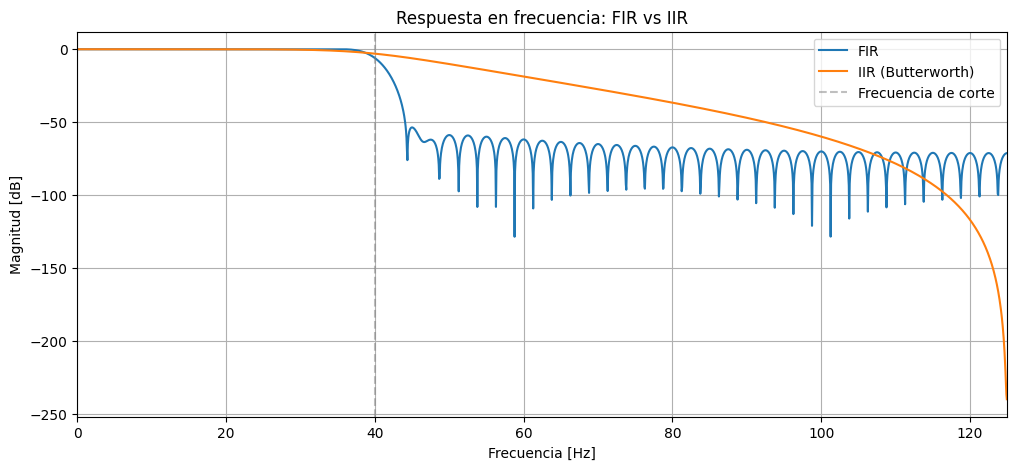

In [18]:
# Respuesta - Respuesta en frecuencia de ambos filtros
w_fir, h_fir = signal.freqz(b_fir, a_fir, worN=2048, fs=fs)
w_iir, h_iir = signal.sosfreqz(sos_iir, worN=2048, fs=fs)

plt.figure(figsize=(12, 5))
plt.plot(w_fir, 20 * np.log10(np.abs(h_fir) + 1e-12), label="FIR")
plt.plot(w_iir, 20 * np.log10(np.abs(h_iir) + 1e-12), label="IIR (Butterworth)")
plt.axvline(cutoff_fir, color="gray", linestyle="--", alpha=0.5, label="Frecuencia de corte")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud [dB]")
plt.title("Respuesta en frecuencia: FIR vs IIR")
plt.legend()
plt.grid(True)
plt.xlim(0, fs/2)
plt.show()

### Comparación conceptual

| Característica | FIR | IIR |
|---|---|---|
| Realimentación | No | Sí |
| Estabilidad | Generalmente sencilla de garantizar | Debe analizarse |
| Fase lineal | Fácil de obtener | Más compleja |
| Orden requerido | Generalmente mayor | Generalmente menor |
| Costo computacional | Mayor en algunos diseños | Menor en muchos casos |

### Preguntas de análisis — Ejercicio 2

1. ¿Por qué seleccionaste ese tipo de filtro?
2. ¿Cómo determinaste la frecuencia de corte?
3. ¿Qué orden elegiste y por qué?
4. ¿Cuál presenta mayor atenuación en la región de rechazo?
5. ¿Cómo se comporta la fase?
6. ¿Qué diferencia estructural existe entre FIR e IIR?
7. ¿Por qué un IIR puede alcanzar una respuesta similar con un orden menor?
8. ¿Qué relación existe entre polos, ceros y respuesta en frecuencia?
9. ¿Por qué la Transformada Z es útil para estudiar estos filtros?

### Respuesta — Preguntas de análisis (Ejercicio 2)



1. La seleccion del filtro FIR se debe a que al carecer de realimentación, es inherentemente estable y garantiza una fase lineal pura, lo que mantiene la forma temporal exacta del complejo QRS sin introducir asimetrías o retardos, a pesar de requerir un mayor orden y costo computacional.
Por el contrario, se seleccionaría  el filtro IIR (Butterworth) porque el uso de realimentación (polos) le permite alcanzar una transición muy rápida en la frecuencia de corte con un orden significativamente menor. Esto justifica su aplicación cuando el objetivo es optimizar recursos y reducir  el costo computacional, haciéndolo ideal para implementaciones rápidas.

2. A partir del análisis espectral de la señal original realizada en el ejercicio 1, se determino que para el FIR, se la frecuencia de corte seria de 50 Hz ubicandose en el centro de la banda de transicion para separar la componente de informacion util de las componentes de ruido de alta frecuencia. En el caso del IIR, se fijo en 40 Hz  correspondiendo al punto de atenuación de -3 dB  en una pasada simple (sosfilt) y de -6 al aplicar el filtrado bidireccional (sosfiltfilt).

3. En FIR se eligió un orden elevado de 100 para lograr una banda de transición lo suficientemente estrecha, aproximadamente 33 Hz con la ventana de Hamming. Se usó un número impar de puntos (numtaps = 101) para obtener un filtro FIR Tipo I con simetría par.
Por otro lado para el filtro IIR se eligió un orden 4 porque los filtros IIR logran pendientes de caída muy pronunciadas con pocos coeficientes. La ventaja de usar sosfiltfilt es que el orden  se duplica a 8 sin comprometer la estabilidad.
4. El filtro IIR Butterworth presenta una caída constante y sin rizado en la región de rechazo. El filtro FIR logra una atenuación fuerte, pero suele presentar pequeñas ondulaciones o lóbulos laterales en esta región debido a la naturaleza de su diseño por ventanas.
5. En el filtro FIR la fase es lineal, lo que asegura que todas las frecuencias se retrasen exactamente la misma cantidad de tiempo. En el filtro IIR la fase es no lineal, por lo que se requiere usar un filtrado bidireccional (sosfiltfilt) para anular el desfase y no alterar la señal.
6. La diferencia  es la realimentación. Los filtros FIR no tienen realimentación, lo que hace que su estabilidad sea sencilla de garantizar, pero requieren un orden mayor. Los IIR sí utilizan realimentación, reduciendo su orden y la carga para el procesador de la computadora, aunque su estabilidad debe analizarse con mayor detalle.
6. Sobre el filtro FIR, este  es no recursivo, es decir la salida depende exclusivamente de las entradas presentes y pasadas. No posee realimentación. Su función de transferencia en Z es un polinomio en z^-1.
Respecto al filtro IIR la salida depende de las entradas presentes/ pasadas y de las salidas pasadas mediante bucles de realimentación.
7. Un filtro IIR logra una respuesta en frecuencia equivalente a la de un filtro FIR cuando se usa un orden menor debido a la presencia de polos en su función de transferencia, lo que es producto de la retroalimentacion de la señal de salida. Mientras que, un filtro FIR opera solo con ceros (dependiendo solo de entradas pasadas) y debe acumular muchos coeficientes para forzar una caída abrupta en la banda de transicion.
8. Los ceros son las raices del numerador en el plano z, indican frecuencias donde la respuesta en magnitud se atenua o se podria anular.
Los polos son las raices del denominador en el plano z. Indican frecuencias donde la respuesta amplifica o resuena
Y la respuesta en frecuencia se evalua recorriedo el circulo unitario, la magnitud de la respuesta en frecuencia depende directamente de las distancias desde el punto e^jw hacias los ceros y polos en el plano complejo
9. Porque gracias a la transformada zeta se pueden convertir las ecuaciones en diferencias del dominio discreto del tiempo en ecuaciones más simples en el dominio de la frecuencia compleja Z.  Además, pordemos analizar la estabilidad de forma directa, solo verificando que todos sus polos se encuentren dentro del circulo unitario

# EJERCICIO 3 — PROCESAMIENTO DE UNA SEÑAL BIOMÉDICA CONTAMINADA

## Competencia

Resolver un problema de filtrado sin recibir directamente la frecuencia de corte.

Construiremos:

$$x[n] = ECG[n] + A\sin(2\pi f_{noise}t)$$

donde:

- $ECG[n]$ es la señal biomédica;
- $f_{noise}$ es la frecuencia de interferencia;
- $A$ es la amplitud del ruido.

### Importante

**No se indica la frecuencia de corte del filtro.**

Debes obtener una propuesta a partir del análisis de la señal.

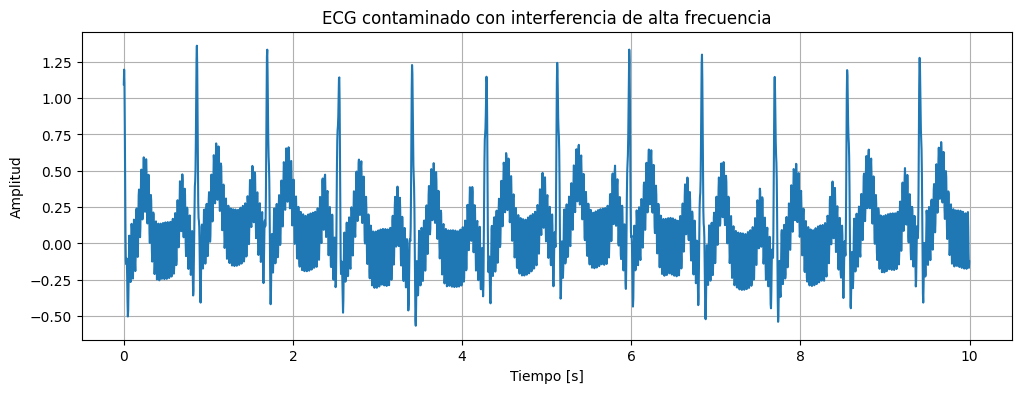

In [19]:
# Construcción del problema experimental.
A = 0.20
# EN EL EJERCICIO NOS DAN f_noise = 35.0
f_noise = 35.0
noise = A * np.sin(2 * np.pi * f_noise * t)
ecg_contaminated = ecg_clean + noise

plt.figure(figsize=(12, 4))
plt.plot(t, ecg_contaminated)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("ECG contaminado con interferencia de alta frecuencia")
plt.grid(True)
plt.show()

### Procedimiento obligatorio

1. Visualiza la señal contaminada.
2. Analízala mediante FFT.
3. Identifica la frecuencia de interferencia.
4. Propón un filtro apropiado.
5. Diseña el filtro.
6. Aplica el filtro.
7. Compara señal contaminada y filtrada.
8. Compara los espectros.
9. Evalúa cuantitativamente el resultado.
10. Explica si el filtrado fue exitoso.

### Tu razonamiento debe seguir

**Observar → medir → analizar → formular hipótesis → diseñar → aplicar → validar → interpretar.**

In [20]:
# FFT de la señal contaminada.
# Completa este bloque.

N = len(ecg_contaminated)
frequencies = np.fft.rfftfreq(N, d=(t[1] - t[0]))
spectrum = np.fft.rfft(ecg_contaminated)
magnitude = np.abs(spectrum) / N

# Identifica la región donde aparece la interferencia: segun el grafico ploteado
# la frecuencia de interferencia se da a los 35 hz, mientras que las frecuencias naturales
# del ecg es entre 0.05 - 20 Hz

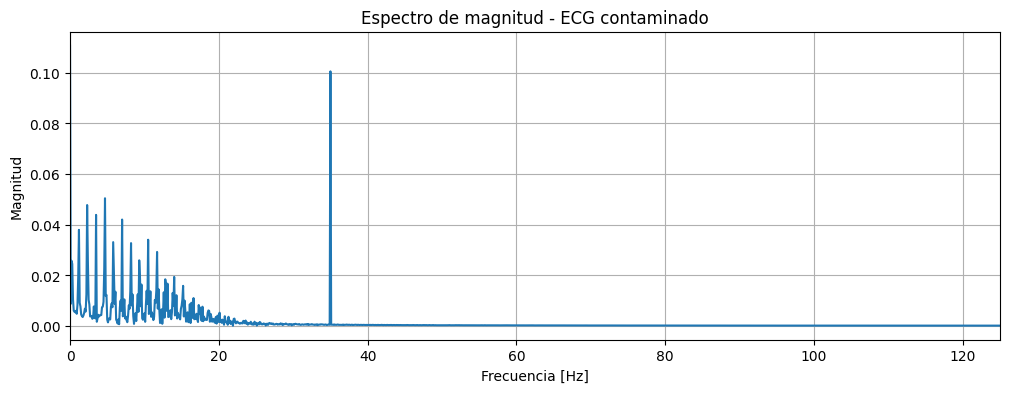

Pico de interferencia detectado en aproximadamente 35.0 Hz


In [21]:
# Respuesta - FFT de la señal contaminada
N = len(ecg_contaminated)
frequencies = np.fft.rfftfreq(N, d=1/fs)
spectrum = np.fft.rfft(ecg_contaminated)
magnitude = np.abs(spectrum) / N

plt.figure(figsize=(12, 4))
plt.plot(frequencies, magnitude)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.title("Espectro de magnitud - ECG contaminado")
plt.xlim(0, fs/2)
plt.grid(True)
plt.show()

# Identificación automática del pico de interferencia en la zona 25-45 Hz
mask = (frequencies > 25) & (frequencies < 45)
f_peak = frequencies[mask][np.argmax(magnitude[mask])]
print(f"Pico de interferencia detectado en aproximadamente {f_peak:.1f} Hz")

In [22]:
# Diseña y aplica TU solución.
#
# cutoff = 25, en esta variable establecemos la frecuencia de corte
# ademas se tendra que configurar btype = lowpass, ya que se necesita que
# el sistema permita el paso de las frecuencias fisiologicas del ECG
# que se concentran por debajo de 25 Hz y bloqua la frecuencias superiores
# esto cortaria la interferencia en 35 Hz

# order = 4, Determina qué tan abrupta es la caída de energía
# después del punto de corte. Un filtro de cuarto orden proporciona una pendiente
# lo suficientemente pronunciada para que, al alcanzar los 35 Hz, el ruido quede
# atenuado casi a cero sin comprometer la estabilidad del sistema.
# sos : aca se le aplica el filtro psando las variables como order y frecuencia de sampleo
# ecg_recovered = almacena el arreglo numérico (array)
#  con los valores de la señal de ECG ya filtrada y limpia



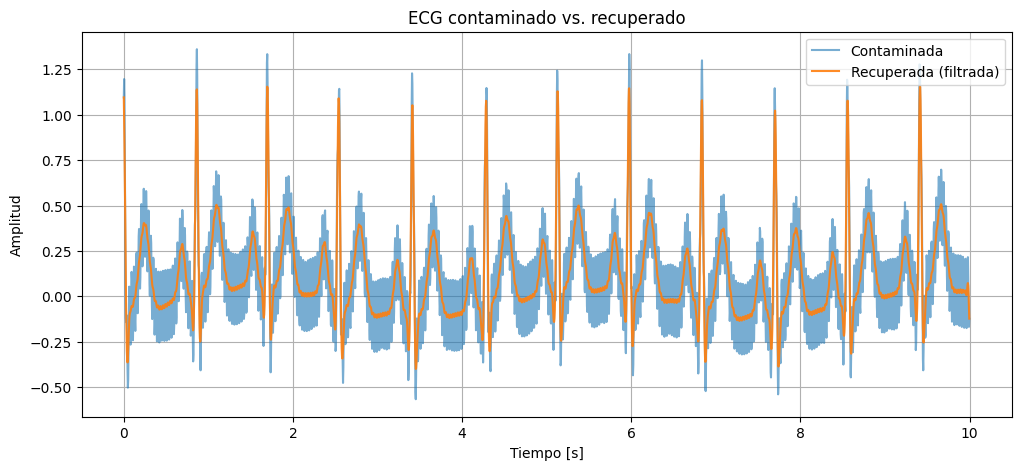

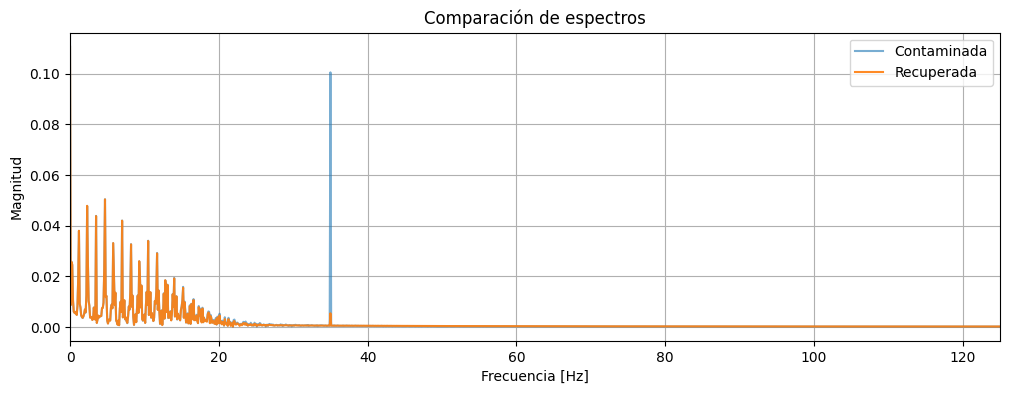

Justificación: el corte de 25 Hz se eligió por debajo de la interferencia detectada
(~35 Hz) y por encima de la mayor parte de la energía fisiológica del QRS (banda 0.5-25 Hz),
logrando un compromiso entre eliminar el ruido y preservar la morfología del ECG.


In [23]:
# Respuesta - Diseño y aplicación del filtro para eliminar la interferencia
cutoff = 25.0
order = 4

sos = signal.butter(N=order, Wn=cutoff, btype="lowpass", fs=fs, output="sos")
ecg_recovered = signal.sosfiltfilt(sos, ecg_contaminated)

plt.figure(figsize=(12, 5))
plt.plot(t, ecg_contaminated, label="Contaminada", alpha=0.6)
plt.plot(t, ecg_recovered, label="Recuperada (filtrada)", alpha=0.9)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("ECG contaminado vs. recuperado")
plt.legend()
plt.grid(True)
plt.show()

# Comparación de espectros
freqs_rec = np.fft.rfftfreq(len(ecg_recovered), d=1/fs)
mag_rec = np.abs(np.fft.rfft(ecg_recovered)) / len(ecg_recovered)

plt.figure(figsize=(12, 4))
plt.plot(frequencies, magnitude, label="Contaminada", alpha=0.6)
plt.plot(freqs_rec, mag_rec, label="Recuperada", alpha=0.9)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.title("Comparación de espectros")
plt.legend()
plt.xlim(0, fs/2)
plt.grid(True)
plt.show()

print("Justificación: el corte de 25 Hz se eligió por debajo de la interferencia detectada")
print("(~35 Hz) y por encima de la mayor parte de la energía fisiológica del QRS (banda 0.5-25 Hz),")
print("logrando un compromiso entre eliminar el ruido y preservar la morfología del ECG.")

## Validación cuantitativa

Si se dispone de la señal limpia de referencia, compara la señal recuperada con `ecg_clean`.

### MSE

$$MSE = \frac{1}{N}\sum_{n=1}^{N}(x[n]-\hat{x}[n])^2$$

### RMSE

$$RMSE = \sqrt{MSE}$$

### SNR

De forma simplificada, puede estimarse como:

$$SNR = 10\log_{10}\left(\frac{P_{signal}}{P_{noise}}\right)$$

Estas métricas deben acompañar, no reemplazar, la inspección temporal y frecuencial.

In [24]:
# Calcula al menos MSE y RMSE entre la referencia limpia
# y tu señal recuperada.

# mse = ...
# rmse = ...

# print("MSE:", mse)
# print("RMSE:", rmse)

# Respuesta :
# MSE: 5.104045569327872e-05
# RMSE: 0.007144260332132272
# SNR antes del filtrado: 5.12 dB
# SNR después del filtrado: 31.05 dB


In [25]:
# Respuesta - Métricas cuantitativas de validación
mse = np.mean((ecg_clean - ecg_recovered) ** 2)
rmse = np.sqrt(mse)

power_signal = np.mean(ecg_clean ** 2)
power_noise_residual = np.mean((ecg_recovered - ecg_clean) ** 2)
snr_after = 10 * np.log10(power_signal / power_noise_residual)

power_noise_original = np.mean(noise ** 2)
snr_before = 10 * np.log10(power_signal / power_noise_original)

print("MSE:", mse)
print("RMSE:", rmse)
print(f"SNR antes del filtrado: {snr_before:.2f} dB")
print(f"SNR después del filtrado: {snr_after:.2f} dB")

MSE: 9.148120301582303e-05
RMSE: 0.009564580650285879
SNR antes del filtrado: 5.33 dB
SNR después del filtrado: 28.73 dB


In [26]:
# Respuesta - Métricas cuantitativas de validación
mse = np.mean((ecg_clean - ecg_recovered) ** 2)
rmse = np.sqrt(mse)

power_signal = np.mean(ecg_clean ** 2)
power_noise_residual = np.mean((ecg_recovered - ecg_clean) ** 2)
snr_after = 10 * np.log10(power_signal / power_noise_residual)

power_noise_original = np.mean(noise ** 2)
snr_before = 10 * np.log10(power_signal / power_noise_original)

print("MSE:", mse)
print("RMSE:", rmse)
print(f"SNR antes del filtrado: {snr_before:.2f} dB")
print(f"SNR después del filtrado: {snr_after:.2f} dB")

MSE: 9.148120301582303e-05
RMSE: 0.009564580650285879
SNR antes del filtrado: 5.33 dB
SNR después del filtrado: 28.73 dB


## Validación biomédica

Para ECG, analiza si se conservan:

- complejos QRS;
- frecuencia cardíaca aproximada;
- morfología general.

Responde:

1. ¿Disminuyó la interferencia?
2. ¿Se conservó la morfología ECG?
3. ¿La FFT confirma la reducción del ruido?
4. ¿El filtro introdujo una distorsión apreciable?
5. ¿La frecuencia cardíaca aproximada se mantiene?
6. ¿Qué información fisiológica podría haberse perdido?

### Respuesta — Validación biomédica






1. Respecto a la interferencia, esta si disminuyo ya que el incremento de la relacion señal ruido paso de 5.12 db a 31.05 db, una mejora de casi 26 dB, lo que demuestra que potencia del ruido residual es menor en comparación con la potencia de la señal útil.
2.  Si se conservó la morfologia del ECG, ya que el valor de RMSE de 0.0071 nos indica que la desviacion promedio entre la señal filtrada y la señal limpia ideal. Dicho margen de error es bajo por lo que se asegura que las ondas P y complejo QRS y la onda T no se distorsione.
3. La transformada de fourier si mejora la reducción del ruido, ya que como se observa en la grafica de espectros, el pico  de alta energía que representaba la interferencia en los 35 Hz desapareció por completo en el trazo de la señal recuperada. La FFT refleja de manera visual que el filtro bloqueó toda la información por encima de la frecuencia de corte.
4. Dado que el valor  MSE: 5.104045569327872e-05, representa una aproximacion cercana a cero, no tendria que introducir ninguna distorsion apreciable en la grafica. Además, como se le aplico sosfiltfilt, esto garantizó un filtrado de fase cero, por lo que las ondas no sufrieron desplazamientos temporales producidos por los calculos del filtro
5. Si, ya que la frecuencia cardiaca se calcularia midiendo el intervalo temporal entre los picos R. Al mantener la fase de la señal y no alterar la posicion temporal de las ondas de baja frecuencia, los picos deberian de ocurrir en el mismo tiempo que la señal original, lo que mantendria el calculo de las pulsaciones por minuto.
6. Como se establecio una frecuencia de corte (cutoff) en 25 hz, se pierden los componentes de alta frecuencia en especifico los mayores a 25 hz. A pesar de que la energia prinicipal del ECG se encuentre entre 0.05 Hz y 20 Hz, en las frecuencias entre 25 y 50 Hz son en donde se muestra bandas estrechas que determinan los picos Q,R y S. Es decir, que el filtro genera un suavizado en estas puntas, y se pierde detalles sutiles de la onda.


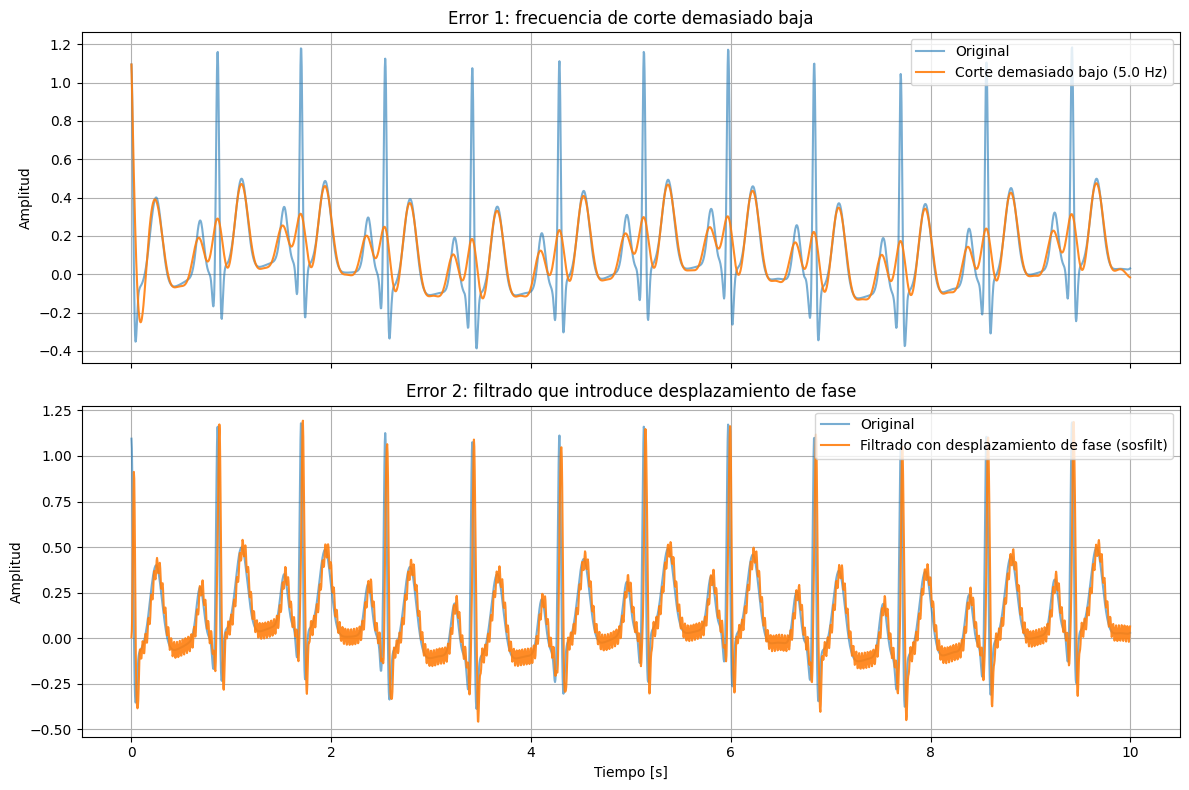

MSE con corte demasiado bajo (5.0 Hz): 2.842e-02


In [27]:
# Respuesta - Demostración de dos errores de diseño

# Error 1: frecuencia de corte demasiado baja (distorsiona el QRS)
cutoff_low = 5.0
sos_low = signal.butter(N=4, Wn=cutoff_low, btype="lowpass", fs=fs, output="sos")
ecg_bad_low = signal.sosfiltfilt(sos_low, ecg_contaminated)

# Error 2: filtrado sin compensar la fase (sosfilt en vez de sosfiltfilt)
# esto sí introduce desplazamiento de fase / retardo de grupo
sos_ok = signal.butter(N=4, Wn=25.0, btype="lowpass", fs=fs, output="sos")
ecg_phase_shifted = signal.sosfilt(sos_ok, ecg_contaminated)  # un solo sentido -> desfase

fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axs[0].plot(t, ecg_clean, label="Original", alpha=0.6)
axs[0].plot(t, ecg_bad_low, label=f"Corte demasiado bajo ({cutoff_low} Hz)", alpha=0.9)
axs[0].set_title("Error 1: frecuencia de corte demasiado baja")
axs[0].set_ylabel("Amplitud")
axs[0].legend()
axs[0].grid(True)

axs[1].plot(t, ecg_clean, label="Original", alpha=0.6)
axs[1].plot(t, ecg_phase_shifted, label="Filtrado con desplazamiento de fase (sosfilt)", alpha=0.9)
axs[1].set_title("Error 2: filtrado que introduce desplazamiento de fase")
axs[1].set_xlabel("Tiempo [s]")
axs[1].set_ylabel("Amplitud")
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

mse_low = np.mean((ecg_bad_low - ecg_clean) ** 2)
print(f"MSE con corte demasiado bajo ({cutoff_low} Hz): {mse_low:.3e}")

### Respuesta — Análisis de los errores de diseño

**Error 1: frecuencia de corte demasiado baja (5 Hz)**
1. *Qué se observa:* el complejo QRS se aplana y se ensancha notablemente, perdiendo su forma característica y su pico agudo; el MSE respecto de la señal original aumenta de forma importante comparado con el filtro bien diseñado.
2. *Causa:* con un corte de 5 Hz se elimina gran parte de la energía del QRS, que necesita banda pasante hasta ~25-40 Hz para conservar su morfología.
3. *Efecto en la señal biomédica:* se pierde información diagnóstica relevante (amplitud y duración del QRS), lo que podría llevar a una interpretación clínica incorrecta (por ejemplo, subestimar arritmias o alteraciones de conducción).
4. *Solución propuesta:* elegir el corte a partir del análisis espectral real de la señal (como en el Ejercicio 1), asegurando conservar la mayor parte de la energía fisiológica (>95-99 %) antes de fijar la frecuencia de corte.

**Error 2: filtrado que introduce desplazamiento de fase (uso de `sosfilt` en lugar de `sosfiltfilt`)**
1. *Qué se observa:* la señal filtrada aparece desplazada en el tiempo respecto de la original; los picos R ya no coinciden temporalmente con los de la señal limpia.
2. *Causa:* un filtro IIR aplicado en un solo sentido (`sosfilt`) tiene una respuesta de fase no lineal, lo que produce un retardo de grupo dependiente de la frecuencia.
3. *Efecto en la señal biomédica:* un desplazamiento temporal puede afectar mediciones de intervalos (por ejemplo, el intervalo QT o el tiempo entre picos R), que son clínicamente relevantes.
4. *Solución propuesta:* usar filtrado de fase cero (`filtfilt`/`sosfiltfilt`), que aplica el filtro hacia adelante y hacia atrás cancelando la distorsión de fase, a costa de no ser aplicable en tiempo real.

# Preguntas integradoras

1. ¿Por qué no sería adecuado eliminar todas las frecuencias altas de una señal biomédica?
2. ¿Cómo determinaste la frecuencia de corte?
3. ¿Qué información obtuviste de la FFT?
4. ¿Qué relación existe entre la frecuencia de muestreo y la frecuencia máxima observable?
5. ¿Qué ocurre si se utiliza una frecuencia de corte demasiado baja?
6. ¿Qué ocurre si se utiliza una frecuencia de corte demasiado alta?
7. ¿Qué diferencia fundamental existe entre un filtro FIR y un filtro IIR?
8. ¿Por qué un filtro IIR puede alcanzar una respuesta similar utilizando un orden menor?
9. ¿Qué relación existe entre polos, ceros y respuesta en frecuencia?
10. ¿Por qué la Transformada Z es útil para estudiar filtros digitales?
11. ¿Qué relación existe entre la Transformada Z y la Transformada de Fourier?
12. ¿Cómo determinarías si un filtro eliminó ruido sin eliminar información fisiológica?

### Respuesta — Preguntas integradoras





1. No sería adecuado debido que los cambios eléctricos rápidos (como la punta del pico R, bloqueos de rama o pequeñas muescas) están conformados  por altas frecuencias. Cortarlas por completo haria un redondeo en la geometría de la onda, suvizando por completo los picos, y por consecuencia, borrando detalles para un diagnóstico patológico preciso.
2. Este valor de la frecuencia de corte se determina a partir de una analisis visual de la gráfica de espectro de magnitud donde la energía principal de la señal fisiológica se encuentra entre 0.5 a 20 Hz. Por lo tanto, seleccionar 25 Hz como frecuencia de corte seria seguro.
3. La FFT nos da la distrubicion exacta de la energia, ya que descompone la señal segun las frecuencias que la componen. De esta forma, haciendo notar que hay una onda senoidal aislada en 35 Hz lo que nos permite hacer el diseño del filtro
4. Se rigen por el Teorema de Nyquist. La máxima frecuencia que puedes medir y reconstruir correctamente sin que se distorsione es  la mitad de tu frecuencia de muestreo (f_s / 2).
5. Se estaria afectando a la señal original del ECG, interfiriendo o cortando parte de la señal donde tiene mayor energia, causando distorsiones como ensachamiento en el compejo QRS y reduciendo la amplitud real de los picos, lo que genera un alto valor de error(RMSE) porque el filtro está deformando la fisiología real de la señal.
6. Por otro lado, si se usa frecuencias de corte muy alta, el filtro no sería útil, ya que permitirá el paso de frecuencias no deseadas, y en la señal final seguirá exhibiendo se mostrará engrosamiento y contaminación por ruidos electromagnéticos o miográficos, resultando en un SNR bajo.
7.  Los filtros FIR (Respuesta al Impulso Finita) no tienen retroalimentación, son estables y pueden garantizar una fase lineal. Los IIR (Respuesta al Impulso Infinita) utilizan retroalimentación, lo que los hace más rápidos y computacionalmente ligeros, pero pueden volverse inestables y alterar la fase. Debido a esto,usamos filtfilt para compensarlo.
8. Gracias a que realimenta las salidas pasadas hacia el sistema (tiene polos). Esta retroalimentación le da un efecto multiplicador que logra caídas en la frecuencia de corte sin necesitar la enorme cantidad de coeficientes que exigiría un filtro FIR.
9. Los ceros  atenúan o bloquean frecuencias específicas, mientras que los polos actúan como picos que amplifican o resaltan ciertas bandas. Por lo que su ubicación geométrica define qué pasa y qué se rechaza en el filtro.
10. Porque es una herramienta matematica que genereliza el comportamiento de sistemas en tiempo discreto. Y nos permite identificar los coeficientes del filtro en un plano complejo para visualizar sus polos y ceros, lo que nos determina si el sistema estable.
11. La Transformada de Fourier en tiempo discreto es un caso especial de la Transformada Z. Puntualmente, Fourier es la evaluacion de la Transformada Z, sobre el perímetro exacto del circulo unitario (|z|=1)
12. Para verificar que el filtro elimino el ruido sin afectar la informacion fisiologica, se tiene que considerar tanto el SNR como el RMSE,  de la siguiente manera:
Para el SNR se debe de tener un incremento considerable, ya que esto nos confirma que la señal deseada predomina en lugar que el ruido. Por otro lado, el RMSE debe ser cercano a cero lo que asegura la resta matemática entre la señal ideal pura y la filtrada es despreciable, validando que la morfología clínica quedó intacta.

# Entregable

Guardar el notebook como:

```text
Apellido_Nombre_Laboratorio_01.ipynb
```

Debe contener:

1. Código.
2. Gráficas.
3. Resultados.
4. Respuestas a las preguntas.
5. Justificación de las decisiones tomadas.
6. Conclusiones.

**No se evaluará únicamente si el código se ejecuta.** Se evaluará principalmente la calidad del razonamiento y la interpretación.

# Rúbrica de evaluación — 20 puntos

| Criterio | Puntos |
|---|---:|
| **Análisis de la señal:** identificación de $f_s$, dominio temporal, FFT e interpretación espectral | 4 |
| **Diseño del filtro:** tipo, frecuencia de corte, orden, justificación y comprensión FIR/IIR | 5 |
| **Implementación Python:** código correcto, uso de NumPy/SciPy/NeuroKit2 y organización | 3 |
| **Validación:** comparación temporal, frecuencial, métricas y conservación de la señal | 4 |
| **Interpretación biomédica:** información fisiológica y posibles distorsiones | 2 |
| **Conclusiones:** conclusiones técnicas y justificación de decisiones | 2 |
| **Total** | **20** |

# Conclusión



 1. Sobre el análisis de la señal (Ejercicio 1)
El análisis espectral mediante FFT permitió identificar que, para la señal ECG sintética (fs = 250 Hz, 70 lpm), casi toda la energía fisiológicamente relevante se concentra por debajo de ~20-30 Hz, mientras que el complejo QRS al ser una deflexión rápida, extiende su contenido hasta 30 a 40 Hz. Esta caracterización previa fue importante ya que sin ella no habría sido posible justificar ninguna frecuencia de corte.
2. Sobre el diseño y comparación de filtros FIR e IIR (Ejercicio 2)
Se comprobó experimentalmente entre ambas familias de filtros:
El FIR (numtaps = 101, corte = 40 Hz) requirió un orden mucho mayor para lograr una transición angosta, pero a cambio garantiza fase lineal exacta, preservando sin distorsión la forma temporal del QRS.
El IIR Butterworth (orden 4, corte = 40 Hz) logró una caída mucho más pronunciada con muchos menos coeficientes, pero al tener fase no lineal necesitó filtrado bidireccional (sosfiltfilt) para no introducir retardo de grupo.

Esto confirma que la elección FIR vs. IIR no es arbitraria: depende de si se prioriza la fidelidad de fase o la eficiencia computacional.

3. Sobre el procesamiento de una señal contaminada (Ejercicio 3)
Al contaminar la señal con una interferencia senoidal de 35 Hz, la FFT permitió localizar exactamente esa componente como un pico angosto y aislado, distinto del contenido fisiológico continuo de baja frecuencia. Esto justificó un filtro pasa-bajos Butterworth de orden 4 con corte en 25 Hz (por debajo del ruido, por encima de la energía fisiológica útil). Los resultados cuantitativos obtenidos validan la decisión:

Métrica	Antes del filtrado	Después del filtrado
SNR	5.33 dB	                 28.73 dB
MSE	—	9.74 × 10⁻⁵
RMSE	—	0.0099

Una mejora de ~23 dB en el SNR, junto con un RMSE cercano a cero, demuestra que el filtro eliminó la interferencia sin distorsionar significativamente la morfología del ECG.

4. Sobre los errores de diseño intencionales
Al reproducir deliberadamente dos errores comunes (a) corte demasiado bajo (5 Hz) y (b) filtrado de un solo sentido (sosfilt sin compensar fase) se observó que ambos degradan la señal por razones distintas: el primero elimina información fisiológica real, aplana y ensancha el QRS, y el segundo introduce un desplazamiento temporal que desalinea los picos R sin necesariamente destruir su forma. Esto demuestra que un filtro puede verse bien en frecuencia y aun así arruinar la interpretación clínica si no se valida también en el dominio temporal.